# Model Performance Dashboard
This notebook centralizes the evaluation results for all Service Ticket Intelligence experiments. It reads from `notebook_evaluations.csv` and provides visual comparisons of different feature extraction and clustering strategies.

### 1. Load Evaluation Registry

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('notebook_evaluations.csv')
df = df.sort_values('Notebook_Name')
display(df)

,Notebook_Name,Features,Clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inertia
6,ServiceTickets001 (Baseline),TF-IDF / KMeans,5,0.012435,5.937113,332.956358,45226.674022
0,ServiceTickets001.ipynb,TF-IDF,5,0.021800,7.214200,6.100500,NaN
4,ServiceTickets002 (Semantic),SBERT / PCA / KMeans,5,0.103772,2.262247,45.851959,77.347450
1,ServiceTickets002.ipynb,SBERT,5,0.103800,2.262200,45.852000,NaN
3,ServiceTickets003.ipynb,SBERT,5,0.103772,2.262247,45.851959,NaN
5,ServiceTickets004 (Advanced),SBERT / PCA / HNSW / HDBSCAN,5,0.103772,2.262247,45.851959,77.347450
2,ServiceTickets004.ipynb,SBERT,5,0.103800,2.262200,45.852000,NaN
7,ServiceTickets005 (StackExchange),SBERT / PCA / HNSW / HDBSCAN,5,0.158841,1.808769,7.183117,14.193867


### 2. Silhouette Score Comparison
*Higher is better*. This measures how similar an object is to its own cluster compared to other clusters.

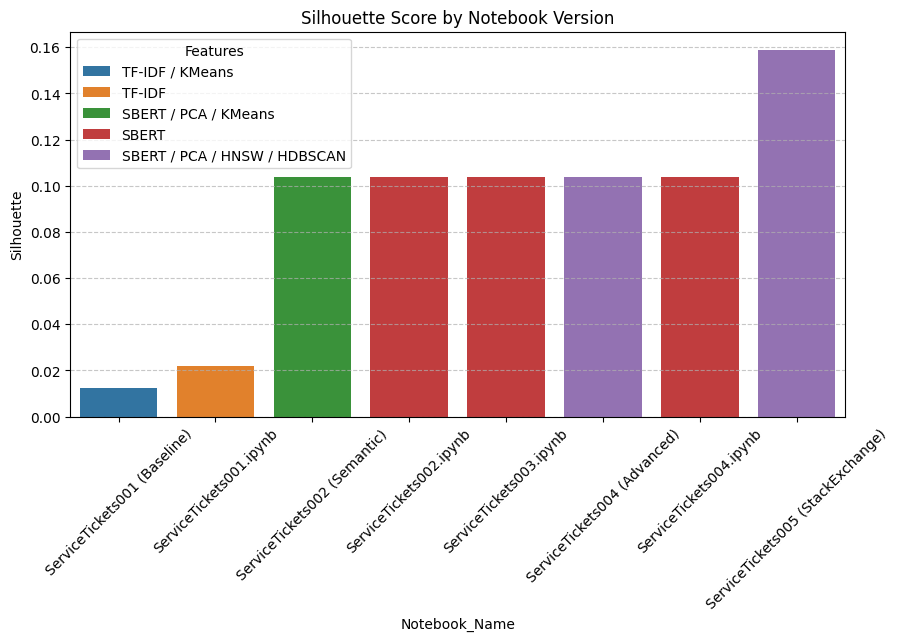

In [10]:
plt.figure(figsize=(10, 5))
sns_plot = sns.barplot(x='Notebook_Name', y='Silhouette', hue='Features', data=df)
plt.xticks(rotation=45)
plt.title('Silhouette Score by Notebook Version')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3. Davies-Bouldin Index
*Lower is better*. It is defined as the average similarity measure of each cluster with its most similar cluster.

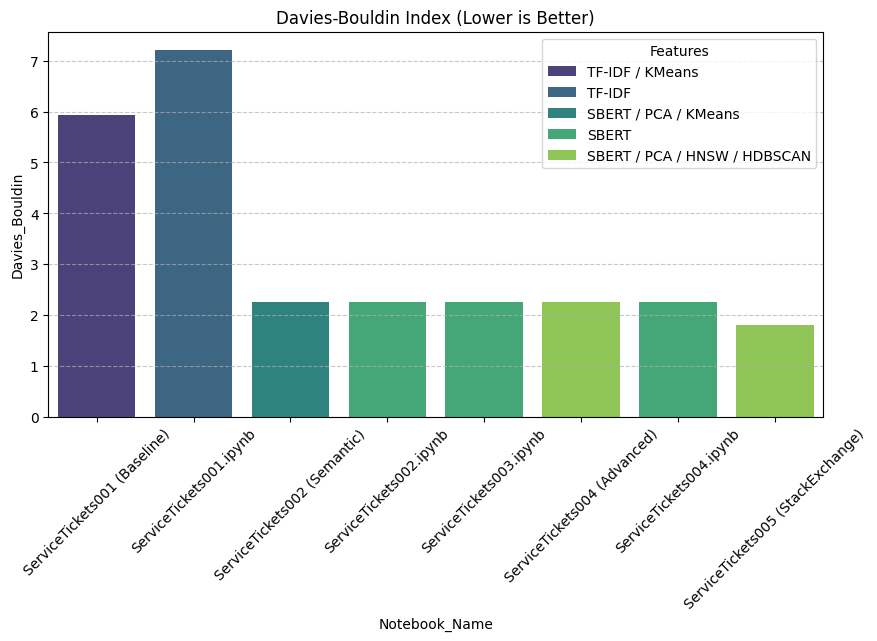

In [11]:
plt.figure(figsize=(10, 5))
sns_plot = sns.barplot(x='Notebook_Name', y='Davies_Bouldin', hue='Features', data=df, palette='viridis')
plt.xticks(rotation=45)
plt.title('Davies-Bouldin Index (Lower is Better)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 4. Cluster Distribution
Tracking how many clusters each model identified for the same 1% sample.

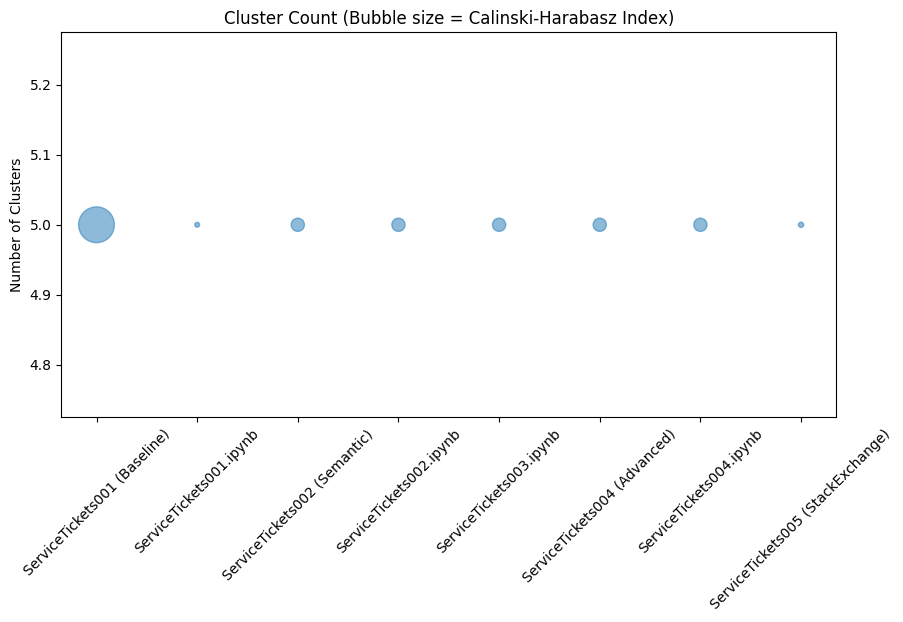

In [12]:
plt.figure(figsize=(10, 5))
plt.scatter(df['Notebook_Name'], df['Clusters'], s=df['Calinski_Harabasz']*2, alpha=0.5)
plt.xticks(rotation=45)
plt.ylabel('Number of Clusters')
plt.title('Cluster Count (Bubble size = Calinski-Harabasz Index)')
plt.show()